In [1]:
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, entropy
import scanpy as sc
from sklearn.preprocessing import LabelEncoder

import scipy.stats as ss


/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/anndata/util

## Load data

In [12]:
adata = sc.read_h5ad('/Users/kylekimler/Projects/GCA/meta_datasets/gca_concatenated_anndata_March19_2025.h5ad')

## Time/resource usage estimation wrapper for all further functions

In [13]:
def profile_function(adata, func, N_values, suppress_output=False, *args, **kwargs):
    import time, tracemalloc, matplotlib.pyplot as plt, numpy as np
    import contextlib, io
    N_sorted = sorted(N_values, reverse=True)
    times = {}
    mems = {}
    largest = N_sorted[0]
    idx = np.random.choice(adata.shape[0], largest, replace=False)
    current_subset = adata[idx,:]
    for N in N_sorted:
        if current_subset.shape[0] > N:
            current_subset = current_subset[np.random.choice(current_subset.shape[0], N, replace=False),:]
        tracemalloc.start()
        start = time.perf_counter()
        if suppress_output:
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                func(current_subset, *args, **kwargs)
        else:
            func(current_subset, *args, **kwargs)
        elapsed = time.perf_counter() - start
        current, peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()
        times[N] = elapsed
        mems[N] = peak / 1024
    return times, mems

def plot_profile(time, mems): 
    sorted_N = sorted(times.keys())
    time_vals = [times[n] for n in sorted_N]
    mem_vals = [mems[n] for n in sorted_N]
    fig1 = plt.figure()
    plt.plot(sorted_N, time_vals)
    plt.xlabel('N')
    plt.ylabel('Time (s)')
    plt.title('Time vs N')
    fig2 = plt.figure()
    plt.plot(sorted_N, mem_vals)
    plt.xlabel('N')
    plt.ylabel('Peak Memory (KB)')
    plt.title('Memory vs N')
    plt.show()

## Metadata correlation plots

In [14]:
def plot_metadata_correlation_heatmap(adata, metadata_columns_to_include, plot_title="Correlation Heatmap of Metadata Variables"):
    metadata=adata.obs[metadata_columns_to_include]
    metadata_encoded=pd.get_dummies(metadata,drop_first=False)
    correlation_matrix=metadata_encoded.corr()
    p_values_matrix=pd.DataFrame(np.zeros_like(correlation_matrix),index=correlation_matrix.index,columns=correlation_matrix.columns)
    for row in correlation_matrix.index:
        for col in correlation_matrix.columns:
            x=metadata_encoded[row]
            y=metadata_encoded[col]
            if hasattr(x,'ndim') and x.ndim>1:
                x=x.values.ravel() if hasattr(x,'values') else np.ravel(x)
            if hasattr(y,'ndim') and y.ndim>1:
                y=y.values.ravel() if hasattr(y,'values') else np.ravel(y)
            _,p_value=pearsonr(x,y)
            p_values_matrix.loc[row,col]=p_value
    def significance_stars(p):
        if p<0.001:
            return "***"
        elif p<0.01:
            return "**"
        elif p<0.05:
            return "*"
        else:
            return ""
    stars_matrix=p_values_matrix.applymap(significance_stars)
    plt.figure(figsize=(14,10))
    cmap=sns.color_palette(['#172984','#8AD6E8'],as_cmap=True)
    sns.heatmap(correlation_matrix,annot=stars_matrix,fmt='',cmap=cmap,center=0,cbar_kws={'label':'Correlation coefficient'})
    plt.title(plot_title)
    plt.xticks(rotation=45,ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


In [13]:
# profile_function(adata, N_values = [100, 500, 2500, 12500], func = plot_metadata_correlation_heatmap,
#                  metadata_columns_to_include=['age_range', 
#                                                                       'sex_ontology_term_id',
#                                                                       'dataset_id',
#                                                                       'sample_id',
#                                                                       'donor_id', 
#                                                                       'tissue_ontology_term_id', 
#                                                                       'sampled_site_condition', 
#                                                                       'radial_tissue_term',
#                                                                       'age_range',
#                                                                       'sample_collection_method',
#                                                                       'alignment_software',
#                                                                       'gene_annotation_version'])

In [18]:
# Titles with metadata

# plot_metadata_correlation_heatmap(sc.pp.subsample(adata, n_obs = 1000), metadata_columns_to_include=['age_range', 
#                                                                       'sex_ontology_term_id',
#                                                                       'dataset_id',
#                                                                       'sample_id',
#                                                                       'donor_id', 
#                                                                       'tissue_ontology_term_id', 
#                                                                       'sampled_site_condition', 
#                                                                       'radial_tissue_term',
#                                                                       'age_range',
#                                                                       'sample_collection_method',
#                                                                       'alignment_software',
#                                                                       'gene_annotation_version'])

## Latent space vs. metadata

In [15]:
def plot_batch_effect_heatmap(adata, latent_space='X_pca', num_pcs=20, metadata_columns_to_include=None, plot_title="Correlation Heatmap of Metadata and PCA Components"):
    # Extract metadata and PCA data from the AnnData object
    metadata = adata.obs[metadata_columns_to_include]
    pca_data = adata.obsm[latent_space][:, :num_pcs]
    pca_data = pd.DataFrame(pca_data, columns=[f'PC{i+1}' for i in range(num_pcs)])
    
    # Convert categorical columns to dummy variables
    categorical_cols = metadata.select_dtypes(include=['object', 'category']).columns
    metadata_encoded = pd.get_dummies(metadata, drop_first=False)
    
    combined_data = pd.concat([metadata_encoded, pca_data], axis=1)
    
    # Calculate the correlation matrix
    correlation_matrix = combined_data.corr()
    
    # Subset the correlation matrix to include only metadata and PCA components
    metadata_columns = metadata_encoded.columns
    pca_columns = pca_data.columns
    subset_correlation_matrix = correlation_matrix.loc[metadata_columns, pca_columns]
    
    # Significance stars
    p_values_matrix = pd.DataFrame(np.zeros_like(subset_correlation_matrix), index=subset_correlation_matrix.index, columns=subset_correlation_matrix.columns)
    
    for row in subset_correlation_matrix.index:
        for col in subset_correlation_matrix.columns:
            _, p_value = pearsonr(combined_data[row], combined_data[col])
            p_values_matrix.loc[row, col] = p_value
    
    def significance_stars(p_value):
        if p_value < 0.001:
            return "***"
        elif p_value < 0.01:
            return "**"
        elif p_value < 0.05:
            return "*"
        else:
            return ""
    
    stars_matrix = p_values_matrix.applymap(significance_stars)
    
    # Plotting
    plt.figure(figsize=(14, 10))
    cmap = sns.color_palette(['#172984','#8AD6E8'], as_cmap=True)
    sns.heatmap(subset_correlation_matrix, annot=stars_matrix, fmt='', cmap=cmap, center=0, cbar_kws={'label': 'Correlation coefficient'})
    plt.title(plot_title)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

## Theil's U

In [16]:
def theils_u(x, y):
    s_xy = entropy(pd.crosstab(x, y).values.flatten(), base=2)
    s_x = entropy(pd.Series(x).value_counts(normalize=True), base=2)
    s_y = entropy(pd.Series(y).value_counts(normalize=True), base=2)
    conditional_entropy = s_xy - s_y
    if s_x == 0:
        return 0
    return (s_x - conditional_entropy) / s_x


def theils_u_heatmap(adata, cols, label_dict=None, save_path = None, dpi=300):
    matrix = pd.DataFrame(index=cols, columns=cols)
    for col1 in cols:
        for col2 in cols:
            matrix.loc[col1, col2] = theils_u(adata.obs[col1], adata.obs[col2])
    if label_dict:
        matrix.rename(index=label_dict, columns=label_dict, inplace=True)
    sns.heatmap(matrix.astype(float), annot=True, fmt=".2f", annot_kws={"size": 6})
    plt.title("Theil's U Heatmap: how well does knowing X allow you to guess Y?")
    if save_path:
        plt.savefig(save_path, dpi=dpi, format='png', bbox_inches='tight')
    plt.show()
    

# Example usage
obs_to_analyze = ['dataset_id', 'donor_id', 'sample_id', 'closest_GCA_celltype', 'gene_annotation_version',
                    'reference_genome', 'alignment_software', 'assay_ontology_term', 'manner_of_death',
                  'radial_tissue_term', 'tissue_ontology_term', 'sample_collection_method', 'sampled_site_condition',
                    'sample_preservation_method', 'suspension_type', 'cell_enrichment', 'age_range']

label_dict = {
    "dataset_id": "Dataset",
    "donor_id": "Donor",
    "sample_id": "Sample",
    "closest_GCA_celltype": "Author Cell Type",
    "gene_annotation_version": "Gene Annotation Version",
    "reference_genome": "Reference Genome",
    "alignment_software": "Alignment Software",
    "assay_ontology_term": "Library Prep Method",
    "manner_of_death": "Manner of Death",
    "radial_tissue_term": "Tissue Dissociation Method",
    "tissue_ontology_term": "GI Tract Location",
    "sample_collection_method": "Biopsy vs Resection",
    "sampled_site_condition": "Disease-Adjacent vs Healthy",
    "sample_preservation_method": "Sample Preservation Method",
    "suspension_type": "Single-Nuclei vs Single-Cell",
    "cell_enrichment": "Cell Enrichment Method",
    "age_range": "Age Range"
}



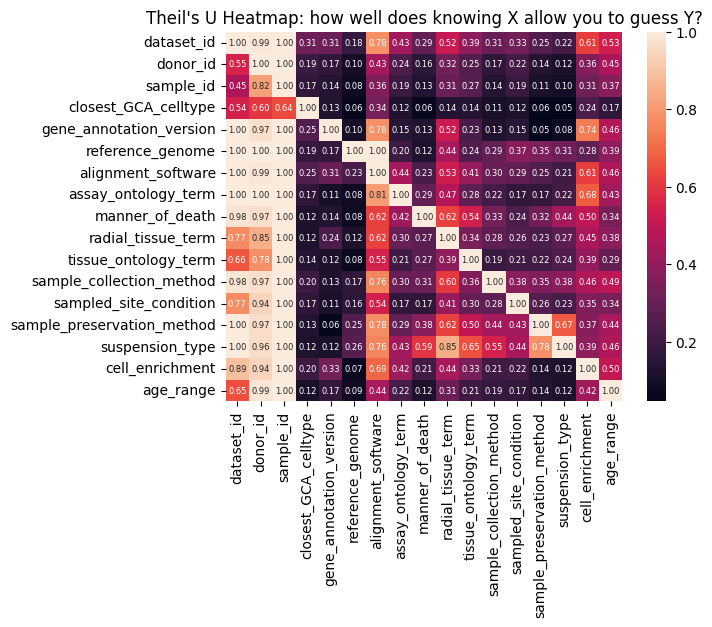

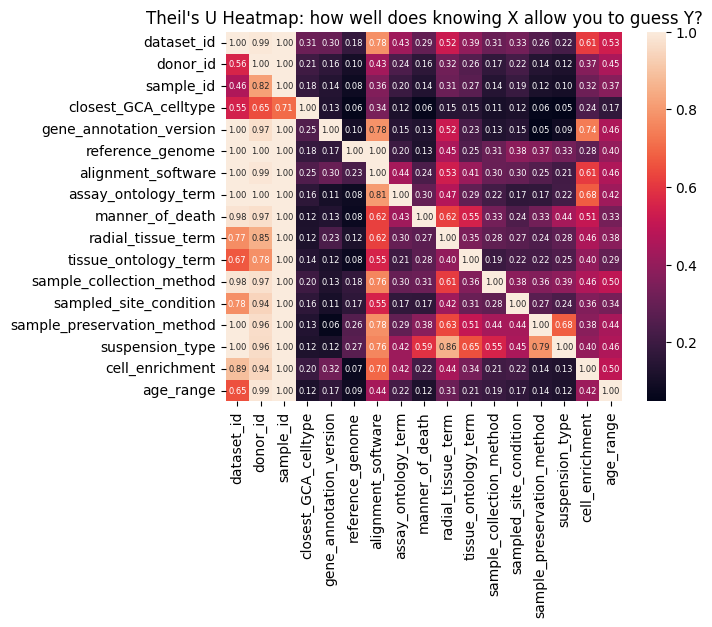

In [19]:
times, mems = profile_function(adata, suppress_output=True,
                               N_values = [12500, 62500], 
                               func = theils_u_heatmap,
                               cols = obs_to_analyze)



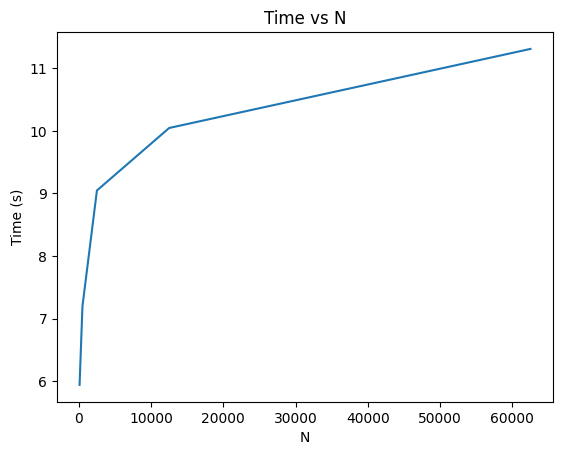

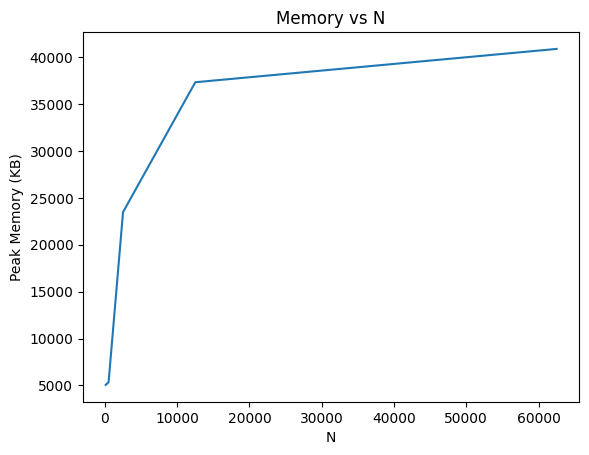

In [13]:
plot_profile(times, mems)

In [17]:
theils_u_heatmap(adata, cols = obs_to_analyze, label_dict = label_dict, save_path = "/Users/kylekimler/Projects/GCA/PVCA/Theils_U_Presentation.png", dpi = 300)



KeyError: 'closest_GCA_celltype'